# Seasonal Temperature Prediction: First Data Check

This group project asks a simple question: Can large-scale climate indices help us predict next-season temperature anomaly at one location?

This notebook is a small MVP. We are not building the final model yet. We are only checking that the four data sources load correctly, have reasonable time ranges, and can be cleaned into simple monthly time series.

The final project will use ERA5 2m temperature, Niño 3.4, PDO, and AO. The main idea is to connect current-season climate signals with next-season temperature anomaly.

In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

## Helper Function

Two of the climate index files use the same layout: one row per year and 12 monthly columns. We keep the file-reading logic in one helper so the dataset sections stay clean and easy to read.

The helper only does simple work: read valid data rows, reshape the monthly values into a time series, sort by date, and replace clear missing-value codes with `NaN`.

In [2]:
# Common display line for cleaner output.
SECTION_LINE = "=" * 60

# Clear missing-value codes used in the climate index files.
MISSING_VALUES = [99.99, -99.99, 999, -999, -9999]

# Read a file with one year and 12 monthly values.
def load_year_month_index(file_path, column_name):
    rows = []

    with open(file_path, "r") as data_file:
        for line in data_file:
            parts = line.split()

            # Keep only rows with one year and 12 months.
            if len(parts) == 13 and parts[0].isdigit():
                year = int(parts[0])

                for month, value in enumerate(parts[1:], start=1):
                    rows.append({
                        "date": pd.Timestamp(year=year, month=month, day=1),
                        column_name: float(value),
                    })

    data = pd.DataFrame(rows).set_index("date").sort_index()
    data = data.replace(MISSING_VALUES, np.nan)

    return data

## Dataset 1: ERA5 2m Temperature

ERA5 is our temperature source. The file is a NetCDF file with monthly 2m air temperature on a global 1x1 grid.

For this first check, we only look at the variable name, dimensions, time range, units, and basic summary statistics. We do not select the final location or compute anomalies yet.

In [3]:
print(SECTION_LINE)
print("DATASET 1: ERA5 2M TEMPERATURE")
print(SECTION_LINE)

# Load the ERA5 temperature file.
era5_data = xr.open_dataset("data/ERA5_2mtemp_1x1.nc")

# Find the temperature variable.
temperature_variable = list(era5_data.data_vars)[0]
era5_temperature = era5_data[temperature_variable]

# Check the basic structure.
print("Temperature variable:", temperature_variable)
print("Dimensions:", dict(era5_temperature.sizes))
print("Time range:", str(era5_temperature.time.min().values)[:10], "to", str(era5_temperature.time.max().values)[:10])
print("Variable description:", era5_temperature.attrs.get("variable", "not listed"))
print("Units:", era5_temperature.attrs.get("units", "not listed"))

# Use float64 only for this summary check.
era5_temperature_check = era5_temperature.astype("float64")

# Make a simple describe-style summary.
era5_description = pd.Series({
    "count": int(era5_temperature_check.count().values),
    "mean": float(era5_temperature_check.mean().values),
    "std": float(era5_temperature_check.std().values),
    "min": float(era5_temperature_check.min().values),
    "max": float(era5_temperature_check.max().values),
})

print("\nDescribe:")
print(era5_description)

DATASET 1: ERA5 2M TEMPERATURE
Temperature variable: __xarray_dataarray_variable__
Dimensions: {'time': 792, 'lat': 180, 'lon': 360}
Time range: 1959-01-01 to 2024-12-01
Variable description: 2m air temperature
Units: K

Describe:
count    5.132160e+07
mean     2.783468e+02
std      2.105701e+01
min      1.999307e+02
max      3.162324e+02
dtype: float64


### What We Learn From ERA5

The ERA5 check tells us that the temperature file is a large monthly global grid from 1959 to 2024. The variable is 2m air temperature, and the units are Kelvin.

The main challenge is not reading the file. The harder choice is how we define a clean local temperature target. We need to choose one location, find the nearest grid cell, convert Kelvin to Celsius, and turn monthly temperature into seasonal temperature anomaly.

What we should watch next:

- The selected location should be easy to explain and meaningful for the project.
- The nearest ERA5 grid cell should be documented clearly.
- The anomaly baseline should be consistent across seasons.
- The final time period must overlap with the climate index data.

## Dataset 2: Niño 3.4 Index

Niño 3.4 is our ENSO index. ENSO is a natural starting point because it can influence seasonal temperature patterns in many regions.

The raw file is stored as yearly rows with 12 monthly values. We reshape it into a monthly time series and clean the obvious missing placeholders.

In [4]:
print(SECTION_LINE)
print("DATASET 2: NIÑO 3.4 INDEX")
print(SECTION_LINE)

# Load Niño 3.4 monthly data.
nino34_data = load_year_month_index("data/nina34.anom.data", "nino34")

# Check the data.
print("Head:")
print(nino34_data.head())
print("\nTail:")
print(nino34_data.tail())
print("\nDescribe:")
print(nino34_data.describe())
print("\nMissing value count:")
print(nino34_data.isna().sum())
print("\nDate range:", nino34_data.index.min(), "to", nino34_data.index.max())

DATASET 2: NIÑO 3.4 INDEX
Head:
            nino34
date              
1948-01-01     NaN
1948-02-01     NaN
1948-03-01     NaN
1948-04-01     NaN
1948-05-01     NaN

Tail:
            nino34
date              
2026-08-01     NaN
2026-09-01     NaN
2026-10-01     NaN
2026-11-01     NaN
2026-12-01     NaN

Describe:
           nino34
count  914.000000
mean    -0.177582
std      0.871255
min     -2.450000
25%     -0.787500
50%     -0.260000
75%      0.350000
max      2.720000

Missing value count:
nino34    34
dtype: int64

Date range: 1948-01-01 00:00:00 to 2026-12-01 00:00:00


### What We Learn From Niño 3.4

The Niño 3.4 file can be reshaped into a clean monthly time series. The missing values mostly appear as placeholder values near the beginning and end of the file.

This index gives us a direct way to represent ENSO. It will probably be one of the most important predictors because ENSO often has seasonal effects on temperature.

What we should watch next:

- We should only use months that overlap with the ERA5 temperature record.
- We need to decide whether to use monthly values, seasonal means, or lagged seasonal means.
- ENSO effects may be stronger in some seasons than others.
- We may want to compare current-season Niño 3.4 with one-season lagged Niño 3.4.

## Dataset 3: PDO Index

PDO is another Pacific climate index. It may capture a slower background pattern that is different from Niño 3.4.

This file has the same year-by-month shape as the Niño 3.4 file, so we use the same helper. The checks below help us confirm the range, missing values, and basic distribution.

In [5]:
print(SECTION_LINE)
print("DATASET 3: PDO INDEX")
print(SECTION_LINE)

# Load PDO monthly data.
pdo_data = load_year_month_index("data/ersst.v5.pdo.dat", "pdo")

# Check the data.
print("Head:")
print(pdo_data.head())
print("\nTail:")
print(pdo_data.tail())
print("\nDescribe:")
print(pdo_data.describe())
print("\nMissing value count:")
print(pdo_data.isna().sum())
print("\nDate range:", pdo_data.index.min(), "to", pdo_data.index.max())

DATASET 3: PDO INDEX
Head:
             pdo
date            
1854-01-01  0.11
1854-02-01 -0.24
1854-03-01 -0.40
1854-04-01 -0.44
1854-05-01 -0.54

Tail:
            pdo
date           
2026-08-01  NaN
2026-09-01  NaN
2026-10-01  NaN
2026-11-01  NaN
2026-12-01  NaN

Describe:
               pdo
count  2067.000000
mean     -0.349748
std       1.160627
min      -4.210000
25%      -1.135000
50%      -0.350000
75%       0.400000
max       3.840000

Missing value count:
pdo    9
dtype: int64

Date range: 1854-01-01 00:00:00 to 2026-12-01 00:00:00


### What We Learn From PDO

The PDO file has a much longer history than the ERA5 temperature file. For our project, the useful part will be the overlapping period with ERA5 and the other climate indices.

PDO may add slower Pacific background information that is different from Niño 3.4. At the same time, it may also be correlated with Niño 3.4, so we should be careful when using both in the same model.

What we should watch next:

- We should align PDO to the same seasonal table as the target variable.
- We should check correlation with Niño 3.4 before interpreting regression coefficients.
- Ridge or Lasso regression may help if the predictors are correlated.
- We should focus on whether PDO improves prediction beyond a simple baseline and Niño 3.4 alone.

## Dataset 4: AO Index

AO is the Arctic Oscillation index. It may be especially useful for cold-season temperature patterns.

This file is already close to a monthly time series. We parse the dates, convert the values to numeric form, set the date index, and clean the missing-value codes.

In [6]:
print(SECTION_LINE)
print("DATASET 4: AO INDEX")
print(SECTION_LINE)

# Load AO monthly data.
ao_data = pd.read_csv(
    "data/ao.long.csv",
    names=["date", "ao"],
    header=0,
    skipinitialspace=True,
)

# Parse dates and values.
ao_data["date"] = pd.to_datetime(ao_data["date"])
ao_data["ao"] = pd.to_numeric(ao_data["ao"], errors="coerce")
ao_data = ao_data.set_index("date").sort_index()

# Replace clear missing values with NaN.
ao_data = ao_data.replace(MISSING_VALUES, np.nan)

# Check the data.
print("Head:")
print(ao_data.head())
print("\nTail:")
print(ao_data.tail())
print("\nDescribe:")
print(ao_data.describe())
print("\nMissing value count:")
print(ao_data.isna().sum())
print("\nDate range:", ao_data.index.min(), "to", ao_data.index.max())

DATASET 4: AO INDEX
Head:
               ao
date             
1950-01-01 -0.060
1950-02-01  0.627
1950-03-01 -0.008
1950-04-01  0.555
1950-05-01  0.072

Tail:
               ao
date             
2025-08-01  0.036
2025-09-01  0.048
2025-10-01  0.064
2025-11-01    NaN
2025-12-01    NaN

Describe:
               ao
count  910.000000
mean    -0.083333
std      0.998798
min     -4.266000
25%     -0.610750
50%     -0.036000
75%      0.496250
max      3.495000

Missing value count:
ao    2
dtype: int64

Date range: 1950-01-01 00:00:00 to 2025-12-01 00:00:00


### What We Learn From AO

The AO file is already close to a clean monthly time series. After parsing the date column and replacing missing placeholders, it is easy to merge with the other climate indices.

AO may be useful because it is connected to atmospheric circulation, especially for cold-season temperature patterns. It may not help equally in every season, so its role should be tested carefully.

What we should watch next:

- We should check whether AO is more useful for winter or cold-season prediction.
- We should avoid claiming that AO helps unless it improves validation results.
- We can include AO in the first regression model, then compare performance with and without it.
- We should keep the interpretation practical: does AO add useful signal for the selected location?

## Simple Combined Data Check

Now we combine the three climate indices into one monthly table. This lets us check the shared structure before we build any seasonal features.

This section is still only EDA. We are not doing regression, train/test splitting, prediction, or residual analysis in this MVP.

In [7]:
print(SECTION_LINE)
print("COMBINED CLIMATE INDICES")
print(SECTION_LINE)

# Combine the three climate indices.
climate_indices = pd.concat([nino34_data, pdo_data, ao_data], axis=1).sort_index()

# Drop rows where all three values are missing.
climate_indices = climate_indices.dropna(how="all")

# Check the combined data.
print("Head:")
print(climate_indices.head())
print("\nTail:")
print(climate_indices.tail())
print("\nDescribe:")
print(climate_indices.describe())
print("\nMissing value count:")
print(climate_indices.isna().sum())
print("\nDate range:", climate_indices.index.min(), "to", climate_indices.index.max())
print("\nCorrelation matrix:")
print(climate_indices.corr())

COMBINED CLIMATE INDICES
Head:
            nino34   pdo  ao
date                        
1854-01-01     NaN  0.11 NaN
1854-02-01     NaN -0.24 NaN
1854-03-01     NaN -0.40 NaN
1854-04-01     NaN -0.44 NaN
1854-05-01     NaN -0.54 NaN

Tail:
            nino34   pdo  ao
date                        
2025-11-01   -0.70 -1.51 NaN
2025-12-01   -0.67 -0.96 NaN
2026-01-01   -0.58 -1.24 NaN
2026-02-01   -0.34 -1.00 NaN
2026-03-01     NaN -1.44 NaN

Describe:
           nino34          pdo          ao
count  914.000000  2067.000000  910.000000
mean    -0.177582    -0.349748   -0.083333
std      0.871255     1.160627    0.998798
min     -2.450000    -4.210000   -4.266000
25%     -0.787500    -1.135000   -0.610750
50%     -0.260000    -0.350000   -0.036000
75%      0.350000     0.400000    0.496250
max      2.720000     3.840000    3.495000

Missing value count:
nino34    1153
pdo          0
ao        1157
dtype: int64

Date range: 1854-01-01 00:00:00 to 2026-03-01 00:00:00

Correlation matrix:
 

/var/folders/66/5m8gb1h54c5c05c3997wt1wm0000gn/T/ipykernel_73462/3131323457.py:6: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  climate_indices = pd.concat([nino34_data, pdo_data, ao_data], axis=1).sort_index()


## One Simple Plot

This plot is only a quick visual check. It helps us see whether the three monthly index series look reasonable after loading and cleaning.

We keep only one plot here so the notebook stays focused on the first data check.

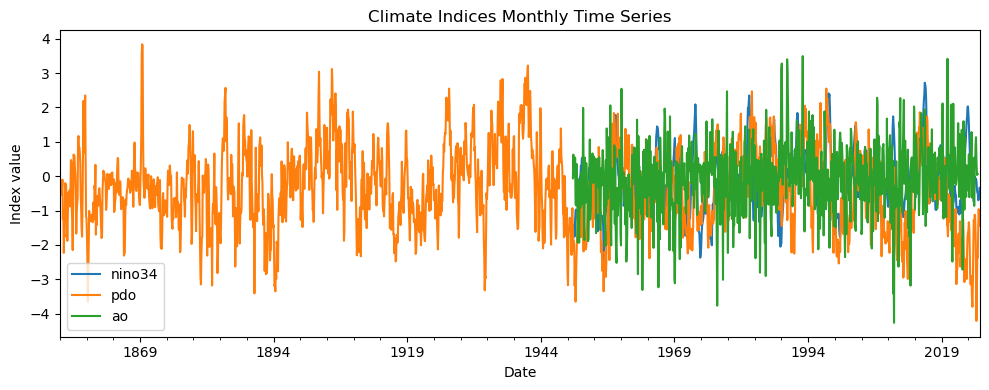

In [8]:
# Plot the three climate indices.
climate_indices.plot(figsize=(10, 4))
plt.title("Climate Indices Monthly Time Series")
plt.xlabel("Date")
plt.ylabel("Index value")
plt.tight_layout()
plt.show()

## What We Have Done So Far

- We loaded the ERA5 2m temperature NetCDF file.
- We confirmed that the ERA5 variable is 2m air temperature in Kelvin.
- We loaded Niño 3.4, PDO, and AO as monthly climate indices.
- We cleaned obvious missing-value codes and converted the index files into date-indexed time series.
- We combined the three climate indices into one monthly table.
- We made one simple plot to check the index time series.

## Next Plan: How We Will Build the Project

### 1. Build the temperature target

- Pick one main location first, such as Boulder, Colorado.
- Extract the nearest ERA5 grid cell for that location.
- Convert ERA5 temperature from Kelvin to Celsius.
- Convert monthly temperature into seasonal means.
- Compute seasonal temperature anomaly by subtracting that season's long-run average.
- Define the response as next-season temperature anomaly.

### 2. Build the climate features

- Convert Niño 3.4, PDO, and AO from monthly values into seasonal means.
- Align current-season climate indices with next-season temperature anomaly.
- Add simple lag features, such as one-season lagged Niño 3.4 or PDO.
- Keep the final modeling table clean: one row per season, one target column, and a small set of predictor columns.

### 3. Try a small set of models

- Start with a baseline model that predicts the historical average anomaly.
- Use multiple linear regression as the first real model.
- Add Ridge or Lasso regression if the predictors are correlated.
- If time allows, compare with a simple tree-based model such as Random Forest or Gradient Boosting.
- Keep the model list small so the story stays clear.

### 4. Evaluate the results

- Use time-based validation instead of a random split.
- Compare models with RMSE, MAE, and correlation between predicted and observed anomaly.
- Check whether the model improves over the baseline.
- Look at which seasons are easier or harder to predict.

### 5. Make the project feel more distinctive

- Show the full pipeline from climate signal to next-season local temperature anomaly.
- Compare skill by season, not just one overall score.
- Use a clean visual summary, such as a season-by-model performance table or heatmap.
- Highlight a few interesting seasons where the climate indices gave a strong signal.
- Keep the final story practical: what can we predict, when does it work, and when does it fail?